<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/Demo_I_Neural_Network_Learning_in_Action_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Demo 1: Neural Network Learning in Action

## Objective
Understand how a neural network learns by combining **mathematical calculations** with **Python implementation**.

---

## 📋 What We'll Cover

| Step | What Happens |
|------|-------------|
| 🔢 **Forward Propagation** | Calculate weighted sum → Apply activation → Generate prediction |
| 📉 **Loss Calculation** | Compare prediction with actual output → Measure error |
| 🔄 **Backpropagation** | Compute gradients → Find how weights caused the error |
| ⚡ **Gradient Descent** | Update weights and biases → Reduce loss |
| 💻 **Python Implementation** | Verify every calculation with code |

---

## 🗺️ Learning Flow

```
Input Data  →  Forward Propagation  →  Prediction  →  Loss Function
                                                            ↓
Better Prediction  ←  Updated Weights  ←  Gradient Descent  ←  Backpropagation
```

---

## 🧩 Structure of This Notebook

- **Part A** — Single Neuron (Regression) — Predict house price
- **Part B** — Single Neuron (Classification) — Predict pass/fail
- **Part C** — Multi-Layer Network — Input → Hidden → Output layer


---
# 🔧 Setup — Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Keras / TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Suppress TF info logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('✅ Libraries imported successfully!')
print(f'   TensorFlow version: {tf.__version__}')

✅ Libraries imported successfully!
   TensorFlow version: 2.20.0


---
# 🏠 PART A — Single Neuron: Regression
## Predicting House Price from Size and Rooms

### 🎯 Problem
Given **size (sq ft)** and **number of rooms**, predict the **house price** (in $100K).

---

### 🧱 Our Neuron — The Building Block

```
  x₁ (size)  ──── w₁ ────┐
                          ├──► [Σ weighted sum + bias] ──► [Linear] ──► ŷ (predicted price)
  x₂ (rooms) ──── w₂ ────┘
                    b (bias)
```

A single neuron does just **two things**:
1. **Weighted sum**: `z = w₁·x₁ + w₂·x₂ + b`
2. **Activation**: `ŷ = activation(z)` — for regression we use **Linear** (no change)


In [ ]:
# ============================================================
# 📌 STEP 1: Define Input Data & True Label
# ============================================================

# Inputs: [size in sq ft (normalised), number of rooms]
x1 = 0.8   # size (normalised: 1600 sq ft → 0.8)
x2 = 0.3   # rooms (normalised: 3 rooms → 0.3)

# True output: house price in $100K
y_true = 2.5   # $250,000

# Initial weights and bias (randomly chosen to start)
w1 = 0.4
w2 = 0.6
b  = 0.1

# Learning rate (how big a step we take when updating weights)
lr = 0.1

print('📥 Input Data')
print(f'   x₁ (size)  = {x1}')
print(f'   x₂ (rooms) = {x2}')
print(f'   y_true     = {y_true}  ($250,000)')
print()
print('⚙️  Initial Parameters')
print(f'   w₁ = {w1},  w₂ = {w2},  b = {b}')
print(f'   Learning rate (η) = {lr}')

📥 Input Data
   x₁ (size)  = 0.8
   x₂ (rooms) = 0.3
   y_true     = 2.5  ($250,000)

⚙️  Initial Parameters
   w₁ = 0.4,  w₂ = 0.6,  b = 0.1
   Learning rate (η) = 0.1


---
## 🔢 Step 2: Forward Propagation — The Math

**The formula:**
$$z = w_1 \cdot x_1 + w_2 \cdot x_2 + b$$

**Substituting values:**
$$z = (0.4 \times 0.8) + (0.6 \times 0.3) + 0.1$$
$$z = 0.32 + 0.18 + 0.1 = 0.60$$

Since this is **regression**, we use a **Linear activation**: $\hat{y} = z$

$$\hat{y} = 0.60 \quad (\mathrm{prediction:\ \$60,000})$$

In [ ]:
# ============================================================
# 🔢 STEP 2: Forward Propagation
# ============================================================

# Weighted sum (linear combination)
z = w1 * x1 + w2 * x2 + b

# Activation: Linear for regression (output = z directly)
y_pred = z

print('🔢 Forward Propagation')
print(f'   z = w₁·x₁ + w₂·x₂ + b')
print(f'   z = ({w1} × {x1}) + ({w2} × {x2}) + {b}')
print(f'   z = {w1*x1:.2f} + {w2*x2:.2f} + {b}')
print(f'   z = {z:.4f}')
print()
print(f'   Activation: Linear → ŷ = z = {y_pred:.4f}')
print(f'   ✏️  Prediction: ${y_pred * 100:.0f},000')

🔢 Forward Propagation
   z = w₁·x₁ + w₂·x₂ + b
   z = (0.4 × 0.8) + (0.6 × 0.3) + 0.1
   z = 0.32 + 0.18 + 0.1
   z = 0.6000

   Activation: Linear → ŷ = z = 0.6000
   ✏️  Prediction: $60,000


---
## 📉 Step 3: Loss Calculation — The Math

We use **Mean Squared Error (MSE)** — the most common loss for regression:

$$\text{Loss} = (y_{\text{true}} - \hat{y})^2$$

**Substituting values:**
$$\text{Loss} = (2.5 - 0.60)^2 = (1.90)^2 = 3.61$$

> A **high loss** means our prediction is far from reality. We need to update the weights!

In [ ]:
# ============================================================
# 📉 STEP 3: Loss Calculation (MSE)
# ============================================================

loss = (y_true - y_pred) ** 2

print('📉 Loss Calculation (Mean Squared Error)')
print(f'   Loss = (y_true - ŷ)²')
print(f'   Loss = ({y_true} - {y_pred:.4f})²')
print(f'   Loss = ({y_true - y_pred:.4f})²')
print(f'   Loss = {loss:.4f}')
print()
print(f'   ❗ Our prediction is ${(y_true - y_pred)*100:.0f},000 away from truth')

📉 Loss Calculation (Mean Squared Error)
   Loss = (y_true - ŷ)²
   Loss = (2.5 - 0.6000)²
   Loss = (1.9000)²
   Loss = 3.6100

   ❗ Our prediction is $190,000 away from truth


---
## 🔄 Step 4: Backpropagation — The Math

**Goal:** Find how much each weight *contributed* to the error.

We use the **chain rule** of calculus to compute gradients.

**Step-by-step:**

1. Gradient of Loss w.r.t. prediction:
$$\frac{\partial L}{\partial \hat{y}} = -2(y_{\text{true}} - \hat{y}) = -2(1.90) = -3.80$$

2. Gradient w.r.t. **w₁** (chain rule: multiply by x₁):
$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial \hat{y}} \cdot x_1 = -3.80 \times 0.8 = -3.04$$

3. Gradient w.r.t. **w₂** (chain rule: multiply by x₂):
$$\frac{\partial L}{\partial w_2} = \frac{\partial L}{\partial \hat{y}} \cdot x_2 = -3.80 \times 0.3 = -1.14$$

4. Gradient w.r.t. **b** (bias has no input, gradient = 1):
$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial \hat{y}} \cdot 1 = -3.80$$

> **Negative gradient** means increasing the weight will *decrease* the loss — we want to go in that direction!

In [ ]:
# ============================================================
# 🔄 STEP 4: Backpropagation — Compute Gradients
# ============================================================

# Gradient of loss w.r.t. prediction
dL_dy = -2 * (y_true - y_pred)

# Gradient of loss w.r.t. each weight (chain rule)
dL_dw1 = dL_dy * x1
dL_dw2 = dL_dy * x2
dL_db  = dL_dy * 1   # bias gradient

print('🔄 Backpropagation — Gradients')
print(f'   ∂L/∂ŷ  = -2 × (y_true - ŷ) = -2 × {y_true - y_pred:.4f} = {dL_dy:.4f}')
print()
print(f'   ∂L/∂w₁ = ∂L/∂ŷ × x₁ = {dL_dy:.4f} × {x1} = {dL_dw1:.4f}')
print(f'   ∂L/∂w₂ = ∂L/∂ŷ × x₂ = {dL_dy:.4f} × {x2} = {dL_dw2:.4f}')
print(f'   ∂L/∂b  = ∂L/∂ŷ × 1  = {dL_db:.4f}')
print()
print('   💡 Negative gradient = increasing the weight reduces the loss')

🔄 Backpropagation — Gradients
   ∂L/∂ŷ  = -2 × (y_true - ŷ) = -2 × 1.9000 = -3.8000

   ∂L/∂w₁ = ∂L/∂ŷ × x₁ = -3.8000 × 0.8 = -3.0400
   ∂L/∂w₂ = ∂L/∂ŷ × x₂ = -3.8000 × 0.3 = -1.1400
   ∂L/∂b  = ∂L/∂ŷ × 1  = -3.8000

   💡 Negative gradient = increasing the weight reduces the loss


---
## ⚡ Step 5: Gradient Descent — The Math

**Update rule** — move weights in the *opposite* direction of the gradient:

$$w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{\partial L}{\partial w}$$

Where $\eta$ = learning rate = 0.1

**Calculating new weights:**
$$w_1^{\text{new}} = 0.4 - 0.1 \times (-3.04) = 0.4 + 0.304 = 0.704$$
$$w_2^{\text{new}} = 0.6 - 0.1 \times (-1.14) = 0.6 + 0.114 = 0.714$$
$$b^{\text{new}} = 0.1 - 0.1 \times (-3.80) = 0.1 + 0.38 = 0.480$$

In [ ]:
# ============================================================
# ⚡ STEP 5: Gradient Descent — Update Weights
# ============================================================

w1_new = w1 - lr * dL_dw1
w2_new = w2 - lr * dL_dw2
b_new  = b  - lr * dL_db

print('⚡ Gradient Descent — Weight Updates')
print(f'   Update rule: w_new = w_old - η × gradient')
print()
print(f'   w₁: {w1} - {lr} × {dL_dw1:.4f} = {w1_new:.4f}  (was {w1})')
print(f'   w₂: {w2} - {lr} × {dL_dw2:.4f} = {w2_new:.4f}  (was {w2})')
print(f'   b:  {b} - {lr} × {dL_db:.4f}  = {b_new:.4f}  (was {b})')

# Verify: new prediction with updated weights
z_new     = w1_new * x1 + w2_new * x2 + b_new
y_pred_new = z_new
loss_new  = (y_true - y_pred_new) ** 2

print()
print('🔁 New Prediction with Updated Weights')
print(f'   ŷ_new = {y_pred_new:.4f}  (was {y_pred:.4f})')
print(f'   Loss_new = {loss_new:.4f}  (was {loss:.4f})')
print(f'   📉 Loss reduced by {loss - loss_new:.4f} — weights improved!')

⚡ Gradient Descent — Weight Updates
   Update rule: w_new = w_old - η × gradient

   w₁: 0.4 - 0.1 × -3.0400 = 0.7040  (was 0.4)
   w₂: 0.6 - 0.1 × -1.1400 = 0.7140  (was 0.6)
   b:  0.1 - 0.1 × -3.8000  = 0.4800  (was 0.1)

🔁 New Prediction with Updated Weights
   ŷ_new = 1.2574  (was 0.6000)
   Loss_new = 1.5441  (was 3.6100)
   📉 Loss reduced by 2.0659 — weights improved!


---
## 💻 Step 6: Full Training Loop — Python (Manual)

Now let's **train for 100 epochs** (iterations) manually and watch the loss drop!

In [ ]:
# ============================================================
# 💻 STEP 6: Full Training Loop — Manual Python
# ============================================================

# Reset weights to originals
w1, w2, b = 0.4, 0.6, 0.1
loss_history = []

print('🏋️  Training the neuron for 100 epochs...')
print(f'{"Epoch":<8} {"ŷ (prediction)":<20} {"Loss":<10}')
print('-' * 40)

for epoch in range(100):
    # --- Forward Pass ---
    z      = w1 * x1 + w2 * x2 + b
    y_pred = z
    loss   = (y_true - y_pred) ** 2
    loss_history.append(loss)

    # --- Backward Pass ---
    dL_dy  = -2 * (y_true - y_pred)
    dL_dw1 = dL_dy * x1
    dL_dw2 = dL_dy * x2
    dL_db  = dL_dy * 1

    # --- Weight Update ---
    w1 -= lr * dL_dw1
    w2 -= lr * dL_dw2
    b  -= lr * dL_db

    # Print every 10 epochs
    if epoch % 10 == 0 or epoch == 99:
        print(f'Epoch {epoch+1:<5} ŷ = {y_pred:.4f} (${y_pred*100:.0f}K)   Loss = {loss:.4f}')

print()
print(f'✅ Training complete!')
print(f'   Final weights: w₁={w1:.4f}, w₂={w2:.4f}, b={b:.4f}')
print(f'   Final prediction: ${y_pred*100:.0f}K  |  True price: ${y_true*100:.0f}K')

🏋️  Training the neuron for 100 epochs...
Epoch    ŷ (prediction)       Loss      
----------------------------------------
Epoch 1     ŷ = 0.6000 ($60K)   Loss = 3.6100
Epoch 11    ŷ = 2.4728 ($247K)   Loss = 0.0007
Epoch 21    ŷ = 2.4996 ($250K)   Loss = 0.0000
Epoch 31    ŷ = 2.5000 ($250K)   Loss = 0.0000
Epoch 41    ŷ = 2.5000 ($250K)   Loss = 0.0000
Epoch 51    ŷ = 2.5000 ($250K)   Loss = 0.0000
Epoch 61    ŷ = 2.5000 ($250K)   Loss = 0.0000
Epoch 71    ŷ = 2.5000 ($250K)   Loss = 0.0000
Epoch 81    ŷ = 2.5000 ($250K)   Loss = 0.0000
Epoch 91    ŷ = 2.5000 ($250K)   Loss = 0.0000
Epoch 100   ŷ = 2.5000 ($250K)   Loss = 0.0000

✅ Training complete!
   Final weights: w₁=1.2786, w₂=0.9295, b=1.1983
   Final prediction: $250K  |  True price: $250K


/tmp/ipykernel_7304/1601742071.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


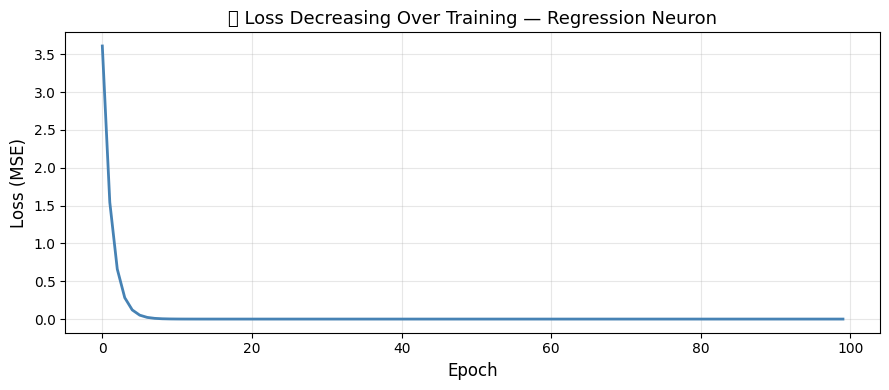

💡 The loss drops steeply at first then flattens — this is normal!


In [ ]:
# ============================================================
# 📊 Visualise Loss Curve
# ============================================================

plt.figure(figsize=(9, 4))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('📉 Loss Decreasing Over Training — Regression Neuron', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('💡 The loss drops steeply at first then flattens — this is normal!')

---
## 🤖 Keras Version — Same Neuron, Same Data

Now let's build the **exact same single neuron** using Keras and verify it learns similarly.

🏗️  Model Architecture


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "single_neuron_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)


✅ Keras Training Complete!
   Final prediction: $250K  |  True price: $250K
   Final loss: 0.0000
**********************************************************************


/tmp/ipykernel_7304/1986632510.py:40: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


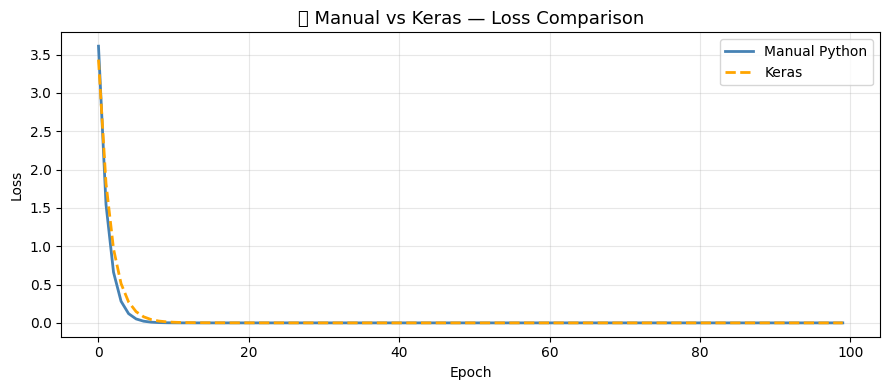

💡 Both curves should overlap — Keras does the same maths under the hood!


In [ ]:
# ============================================================
# 🤖 Keras: Single Neuron Regression
# ============================================================

# Input: 1 sample, 2 features
X_reg = np.array([[0.8, 0.3]])   # [size, rooms]
Y_reg = np.array([[2.5]])         # price

# Build model: 1 Dense layer, 1 neuron, linear activation
model_reg = keras.Sequential([
    layers.Dense(1, activation='linear', input_shape=(2,),
                 kernel_initializer=keras.initializers.Constant([0.4, 0.6]),
                 bias_initializer=keras.initializers.Constant(0.1))
], name='single_neuron_regression')

model_reg.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1),
                  loss='mse')

print('🏗️  Model Architecture')
model_reg.summary()

# Train for 100 epochs
history_reg = model_reg.fit(X_reg, Y_reg, epochs=100, verbose=0)

# Results
final_pred = model_reg.predict(X_reg, verbose=0)[0][0]
final_loss = history_reg.history['loss'][-1]

print()
print(f'✅ Keras Training Complete!')
print(f'   Final prediction: ${final_pred*100:.0f}K  |  True price: $250K')
print(f'   Final loss: {final_loss:.4f}')
print("*"*70)
# Compare loss curves
plt.figure(figsize=(9, 4))
plt.plot(loss_history,                 label='Manual Python', color='steelblue', linewidth=2)
plt.plot(history_reg.history['loss'],  label='Keras',         color='orange',    linewidth=2, linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('📊 Manual vs Keras — Loss Comparison', fontsize=13)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()
print('💡 Both curves should overlap — Keras does the same maths under the hood!')

---
# ✅ PART B — Single Neuron: Classification
## Predicting Pass / Fail from Study Hours and Sleep Hours

### 🎯 Problem
Given **study hours** and **sleep hours**, predict if a student **passes (1) or fails (0)**.

---

### 🔑 Key Difference from Regression

| | Regression | Classification |
|--|--|--|
| **Output** | Continuous number | 0 or 1 |
| **Activation** | Linear | **Sigmoid** |
| **Loss** | MSE | **Binary Cross-Entropy** |

### 🌀 Sigmoid Activation Function

Squashes any number into a range between **0 and 1** (a probability):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

In [ ]:
# ============================================================
# 📌 STEP 1: Inputs and Setup — Classification
# ============================================================

# Inputs: [study hours (normalised), sleep hours (normalised)]
x1_c = 0.7   # 7 hours study → 0.7
x2_c = 0.5   # 5 hours sleep → 0.5

# True label: 1 = Pass, 0 = Fail
y_true_c = 1

# Initial weights
w1_c = 0.3
w2_c = 0.5
b_c  = -0.2
lr_c = 0.1

print('📥 Classification Input')
print(f'   x₁ (study hours) = {x1_c}  (7 hrs)')
print(f'   x₂ (sleep hours) = {x2_c}  (5 hrs)')
print(f'   y_true = {y_true_c}  (Pass)')
print()
print(f'⚙️  Initial Weights: w₁={w1_c}, w₂={w2_c}, b={b_c}')

📥 Classification Input
   x₁ (study hours) = 0.7  (7 hrs)
   x₂ (sleep hours) = 0.5  (5 hrs)
   y_true = 1  (Pass)

⚙️  Initial Weights: w₁=0.3, w₂=0.5, b=-0.2


---
## 🔢 Forward Propagation — Classification Math

**Step 1 — Weighted sum:**
$$z = w_1 \cdot x_1 + w_2 \cdot x_2 + b = (0.3 \times 0.7) + (0.5 \times 0.5) + (-0.2)$$
$$z = 0.21 + 0.25 - 0.20 = 0.26$$

**Step 2 — Sigmoid activation:**
$$\hat{y} = \sigma(0.26) = \frac{1}{1 + e^{-0.26}} = \frac{1}{1 + 0.771} = 0.565$$

> This means: **56.5% probability of passing** — better than random, but we can improve!

In [ ]:
# ============================================================
# 🔢 Forward Propagation — Classification
# ============================================================

def sigmoid(z):
    """Sigmoid: squashes z into (0, 1)"""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """Derivative of sigmoid: σ(z) × (1 - σ(z))"""
    s = sigmoid(z)
    return s * (1 - s)

# Forward pass
z_c      = w1_c * x1_c + w2_c * x2_c + b_c
y_pred_c = sigmoid(z_c)

print('🔢 Forward Propagation (Classification)')
print(f'   z = ({w1_c} × {x1_c}) + ({w2_c} × {x2_c}) + ({b_c})')
print(f'   z = {w1_c*x1_c:.2f} + {w2_c*x2_c:.2f} + ({b_c}) = {z_c:.4f}')
print()
print(f'   Sigmoid(z) = 1 / (1 + e^(-{z_c:.4f}))')
print(f'              = 1 / (1 + {np.exp(-z_c):.4f})')
print(f'              = {y_pred_c:.4f}')
print()
print(f'   ✏️  Prediction: {y_pred_c*100:.1f}% probability of PASSING')

🔢 Forward Propagation (Classification)
   z = (0.3 × 0.7) + (0.5 × 0.5) + (-0.2)
   z = 0.21 + 0.25 + (-0.2) = 0.2600

   Sigmoid(z) = 1 / (1 + e^(-0.2600))
              = 1 / (1 + 0.7711)
              = 0.5646

   ✏️  Prediction: 56.5% probability of PASSING


---
## 📉 Loss — Binary Cross-Entropy

For classification, we use **Binary Cross-Entropy** (BCE) loss:

$$L = -[y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y})]$$

**Substituting** (y=1, so the second term drops out):
$$L = -[1 \cdot \log(0.565)] = -\log(0.565) = 0.571$$

> **Lower BCE = better prediction.** A perfect prediction (ŷ=1, y=1) gives L=0.

In [ ]:
# ============================================================
# 📉 Loss — Binary Cross-Entropy
# ============================================================

eps = 1e-8  # prevent log(0)
bce_loss = -(y_true_c * np.log(y_pred_c + eps) + (1 - y_true_c) * np.log(1 - y_pred_c + eps))

print('📉 Binary Cross-Entropy Loss')
print(f'   L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]')
print(f'   L = -[{y_true_c}·log({y_pred_c:.4f}) + {1-y_true_c}·log({1-y_pred_c:.4f})]')
print(f'   L = -[{y_true_c * np.log(y_pred_c):.4f} + 0]')
print(f'   L = {bce_loss:.4f}')

📉 Binary Cross-Entropy Loss
   L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]
   L = -[1·log(0.5646) + 0·log(0.4354)]
   L = -[-0.5716 + 0]
   L = 0.5716


---
## 🔄 Backpropagation + ⚡ Gradient Descent — Classification

**Gradient of BCE loss through sigmoid** simplifies beautifully to:

$$\frac{\partial L}{\partial z} = \hat{y} - y = 0.565 - 1 = -0.435$$

Then:
$$\frac{\partial L}{\partial w_1} = (\hat{y} - y) \cdot x_1 = -0.435 \times 0.7 = -0.3045$$
$$\frac{\partial L}{\partial w_2} = (\hat{y} - y) \cdot x_2 = -0.435 \times 0.5 = -0.2175$$

In [ ]:
# ============================================================
# 🔄 Backprop + ⚡ Gradient Descent — Classification
# ============================================================

# Gradient (BCE + Sigmoid combined)
dL_dz_c  = y_pred_c - y_true_c          # ŷ - y
dL_dw1_c = dL_dz_c * x1_c
dL_dw2_c = dL_dz_c * x2_c
dL_db_c  = dL_dz_c * 1

print('🔄 Backpropagation')
print(f'   ∂L/∂z  = ŷ - y = {y_pred_c:.4f} - {y_true_c} = {dL_dz_c:.4f}')
print(f'   ∂L/∂w₁ = {dL_dz_c:.4f} × {x1_c} = {dL_dw1_c:.4f}')
print(f'   ∂L/∂w₂ = {dL_dz_c:.4f} × {x2_c} = {dL_dw2_c:.4f}')
print(f'   ∂L/∂b  = {dL_db_c:.4f}')

# Weight update
w1_c_new = w1_c - lr_c * dL_dw1_c
w2_c_new = w2_c - lr_c * dL_dw2_c
b_c_new  = b_c  - lr_c * dL_db_c

print()
print('⚡ Weight Updates')
print(f'   w₁: {w1_c} → {w1_c_new:.4f}')
print(f'   w₂: {w2_c} → {w2_c_new:.4f}')
print(f'   b:  {b_c} → {b_c_new:.4f}')

# Verify new prediction
z_new_c   = w1_c_new * x1_c + w2_c_new * x2_c + b_c_new
y_new_c   = sigmoid(z_new_c)
print()
print(f'   New prediction: {y_new_c*100:.1f}%  (was {y_pred_c*100:.1f}%)  → Improved! 📈')

🔄 Backpropagation
   ∂L/∂z  = ŷ - y = 0.5646 - 1 = -0.4354
   ∂L/∂w₁ = -0.4354 × 0.7 = -0.3048
   ∂L/∂w₂ = -0.4354 × 0.5 = -0.2177
   ∂L/∂b  = -0.4354

⚡ Weight Updates
   w₁: 0.3 → 0.3305
   w₂: 0.5 → 0.5218
   b:  -0.2 → -0.1565

   New prediction: 58.3%  (was 56.5%)  → Improved! 📈


/tmp/ipykernel_7304/877748919.py:33: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7304/877748919.py:33: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


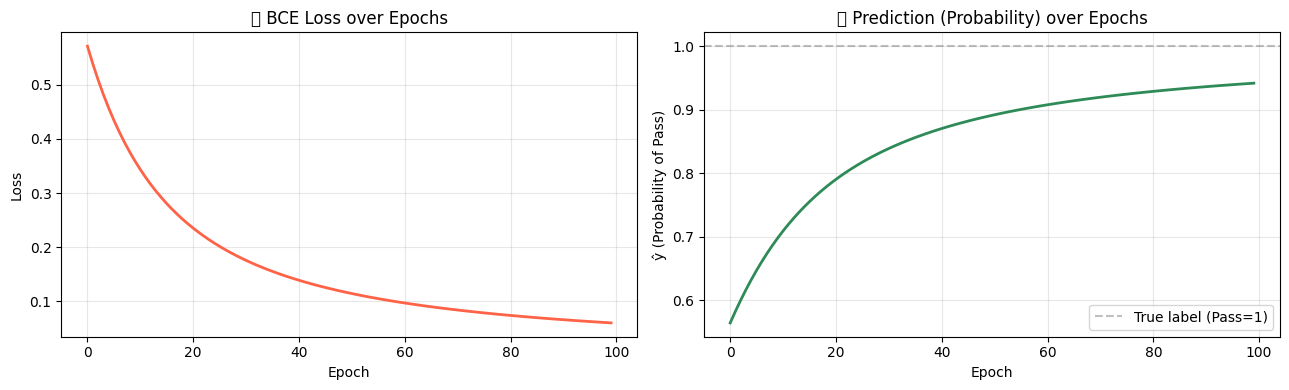

✅ Final probability of passing: 94.2%
   Final decision: PASS ✅


In [ ]:
# ============================================================
# 💻 Full Training Loop — Classification
# ============================================================

w1_c, w2_c, b_c = 0.3, 0.5, -0.2
loss_history_c = []
pred_history_c = []

for epoch in range(100):
    z_c      = w1_c * x1_c + w2_c * x2_c + b_c
    y_pred_c = sigmoid(z_c)
    bce      = -(y_true_c * np.log(y_pred_c + 1e-8) + (1-y_true_c) * np.log(1-y_pred_c+1e-8))
    loss_history_c.append(bce)
    pred_history_c.append(y_pred_c)

    dL_dz  = y_pred_c - y_true_c
    w1_c  -= lr_c * dL_dz * x1_c
    w2_c  -= lr_c * dL_dz * x2_c
    b_c   -= lr_c * dL_dz

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(loss_history_c, color='tomato', linewidth=2)
ax1.set_title('📉 BCE Loss over Epochs', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True, alpha=0.3)

ax2.plot(pred_history_c, color='seagreen', linewidth=2)
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='True label (Pass=1)')
ax2.set_title('📈 Prediction (Probability) over Epochs', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ŷ (Probability of Pass)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'✅ Final probability of passing: {pred_history_c[-1]*100:.1f}%')
print(f'   Final decision: {"PASS ✅" if pred_history_c[-1] >= 0.5 else "FAIL ❌"}')

---
## 🤖 Keras Version — Classification Neuron

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

X_cls = np.array([[0.7, 0.5]])
Y_cls = np.array([[1.0]])

model_cls = keras.Sequential([
    layers.Dense(
        1,
        activation='sigmoid',
        input_shape=(2,),
        kernel_initializer=keras.initializers.Constant(
            [[0.3],
             [0.5]]
        ),
        bias_initializer=keras.initializers.Constant(-0.2)
    )
])

model_cls.summary()

model_cls.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cls = model_cls.fit(
    X_cls,
    Y_cls,
    epochs=100,
    verbose=0
)

final_prob = model_cls.predict(X_cls, verbose=0)[0][0]

print(f"Probability: {final_prob:.4f}")
print(f"Decision: {'PASS ✅' if final_prob >= 0.5 else 'FAIL ❌'}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Probability: 0.9423
Decision: PASS ✅


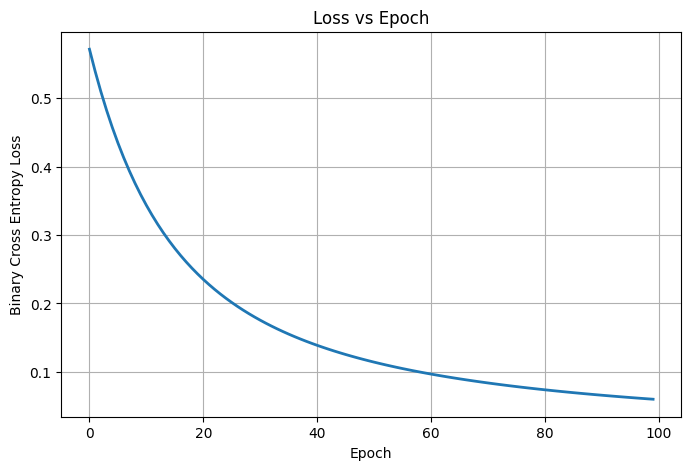

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_cls.history['loss'], linewidth=2)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.show()

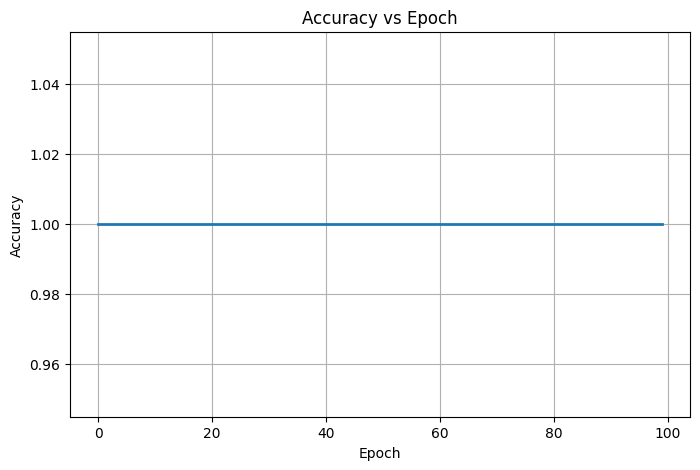

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_cls.history['accuracy'], linewidth=2)
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

---
# 🏗️ PART C — Multi-Layer Network
## Input Layer → Hidden Layer → Output Layer

### 🎯 Problem
Predict whether a student **passes or fails** using a slightly more complex dataset with **4 students**, **2 features**, and a **hidden layer** of 3 neurons.

---

### 🧱 Network Architecture

```
INPUT LAYER        HIDDEN LAYER         OUTPUT LAYER
(2 neurons)        (3 neurons)          (1 neuron)

  x₁ ──────── h₁  ──────┐
       \    ╱           |
  x₂ ────  h₂ ────────── ├──► ŷ (Pass/Fail)
       ╲    ╲           │
         ─── h₃ ────────┘

Activation: ReLU       Activation: Sigmoid
Loss: Binary Cross-Entropy
```

### 🔑 New Activation — ReLU

$$\text{ReLU}(z) = \max(0, z)$$

If z is negative → output 0. If z is positive → output z. Simple and effective!

In [ ]:
# ============================================================
# 📌 Dataset: 4 Students
# ============================================================

# Features: [study_hours (normalised), sleep_hours (normalised)]
X_multi = np.array([
    [0.9, 0.8],   # Student A: studies a lot, sleeps well
    [0.2, 0.3],   # Student B: doesn't study, poor sleep
    [0.7, 0.4],   # Student C: studies moderately
    [0.4, 0.9],   # Student D: sleeps well but little study
])

# Labels: 1=Pass, 0=Fail
Y_multi = np.array([[1], [0], [1], [0]])

print('📋 Dataset')
print(f'{"Student":<12} {"Study (x₁)":<14} {"Sleep (x₂)":<14} {"Label"}')
print('-' * 50)
labels = ['A', 'B', 'C', 'D']
for i, (x, y) in enumerate(zip(X_multi, Y_multi)):
    outcome = '✅ Pass' if y[0] == 1 else '❌ Fail'
    print(f'Student {labels[i]:<5} {x[0]:<14} {x[1]:<14} {outcome}')

📋 Dataset
Student      Study (x₁)     Sleep (x₂)     Label
--------------------------------------------------
Student A     0.9            0.8            ✅ Pass
Student B     0.2            0.3            ❌ Fail
Student C     0.7            0.4            ✅ Pass
Student D     0.4            0.9            ❌ Fail


---
## 🔢 Manual Forward Pass — Multi-Layer Math

Let's trace through **Student A** manually with random initial weights.

**Hidden layer** (3 neurons, ReLU activation):
$$h_j = \text{ReLU}\left(\sum_i w_{ij} \cdot x_i + b_j\right)$$

**Output layer** (1 neuron, Sigmoid activation):
$$\hat{y} = \sigma\left(\sum_j v_j \cdot h_j + b_{\text{out}}\right)$$

In [ ]:
# ============================================================
# 🔢 Manual Forward Pass — Multi-Layer (Student A)
# ============================================================

np.random.seed(42)

# Input → Hidden weights: shape (2 inputs, 3 hidden neurons)
W1 = np.array([[0.5, -0.2,  0.4],
               [0.3,  0.6, -0.1]])
b1 = np.array([0.1, 0.0, -0.1])   # biases for hidden layer

# Hidden → Output weights: shape (3 hidden, 1 output)
W2 = np.array([[0.7], [-0.3], [0.5]])
b2 = np.array([0.0])               # bias for output

# Take Student A as input
x_A = X_multi[0]   # [0.9, 0.8]
y_A = Y_multi[0]   # [1]

print('👤 Student A Input:', x_A, '  |  True label:', y_A[0])
print()

# --- Hidden Layer ---
z1 = x_A @ W1 + b1          # shape: (3,)
a1 = np.maximum(0, z1)       # ReLU

print('🔷 Hidden Layer')
print(f'   z1 (pre-activation) = x·W1 + b1 = {z1.round(4)}')
print(f'   a1 (after ReLU)     = max(0, z1) = {a1.round(4)}')
print()

# --- Output Layer ---
z2 = a1 @ W2 + b2            # shape: (1,)
y_hat = sigmoid(z2[0])

print('🔶 Output Layer')
print(f'   z2 (pre-activation) = a1·W2 + b2 = {z2.round(4)}')
print(f'   ŷ  (after Sigmoid)  = σ(z2) = {y_hat:.4f}')
print()
print(f'   ✏️  Prediction: {y_hat*100:.1f}% → {"PASS ✅" if y_hat >= 0.5 else "FAIL ❌"}')

# Loss
loss_A = -(y_A[0] * np.log(y_hat + 1e-8) + (1 - y_A[0]) * np.log(1 - y_hat + 1e-8))
print(f'   BCE Loss: {loss_A:.4f}')

👤 Student A Input: [0.9 0.8]   |  True label: 1

🔷 Hidden Layer
   z1 (pre-activation) = x·W1 + b1 = [0.79 0.3  0.18]
   a1 (after ReLU)     = max(0, z1) = [0.79 0.3  0.18]

🔶 Output Layer
   z2 (pre-activation) = a1·W2 + b2 = [0.553]
   ŷ  (after Sigmoid)  = σ(z2) = 0.6348

   ✏️  Prediction: 63.5% → PASS ✅
   BCE Loss: 0.4544


---
## 🏗️ Build & Train with Keras — Multi-Layer Network

In [ ]:
# ============================================================
# 🤖 Keras: Input → Hidden → Output
# ============================================================

model_multi = keras.Sequential([
    # Hidden Layer: 3 neurons, ReLU
    layers.Dense(3, activation='relu', input_shape=(2,), name='hidden_layer'),
    # Output Layer: 1 neuron, Sigmoid
    layers.Dense(1, activation='sigmoid', name='output_layer')
], name='multi_layer_network')

model_multi.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('🏗️  Multi-Layer Network Architecture')
model_multi.summary()
print()
print('Layer details:')
print('  Hidden Layer  → 3 neurons, ReLU activation')
print('  Output Layer  → 1 neuron, Sigmoid activation')
print('  Loss          → Binary Cross-Entropy')
print('  Optimiser     → SGD (learning rate = 0.5)')

🏗️  Multi-Layer Network Architecture


Model: "multi_layer_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)


Layer details:
  Hidden Layer  → 3 neurons, ReLU activation
  Output Layer  → 1 neuron, Sigmoid activation
  Loss          → Binary Cross-Entropy
  Optimiser     → SGD (learning rate = 0.5)


In [ ]:
# ============================================================
# 🏋️ Train the Multi-Layer Network
# ============================================================

history_multi = model_multi.fit(
    X_multi, Y_multi,
    epochs=200,
    verbose=0
)

print('✅ Training Complete!')
print()

# Predictions for all students
preds = model_multi.predict(X_multi, verbose=0)
print(f'{"Student":<12} {"True Label":<14} {"Predicted Prob":<18} {"Decision"}')
print('-' * 55)
for i, (pred, true) in enumerate(zip(preds, Y_multi)):
    decision = '✅ Pass' if pred[0] >= 0.5 else '❌ Fail'
    correct  = '☑' if (pred[0] >= 0.5) == bool(true[0]) else '✗'
    print(f'Student {labels[i]:<5} {true[0]:<14} {pred[0]:.4f}           {decision} {correct}')

final_acc = history_multi.history['accuracy'][-1]
print(f'\n   Final Training Accuracy: {final_acc*100:.0f}%')

✅ Training Complete!

Student      True Label     Predicted Prob     Decision
-------------------------------------------------------
Student A     1              0.9940           ✅ Pass ☑
Student B     0              0.0417           ❌ Fail ☑
Student C     1              0.9834           ✅ Pass ☑
Student D     0              0.0417           ❌ Fail ☑

   Final Training Accuracy: 100%


/tmp/ipykernel_7304/4209129750.py:19: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7304/4209129750.py:19: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


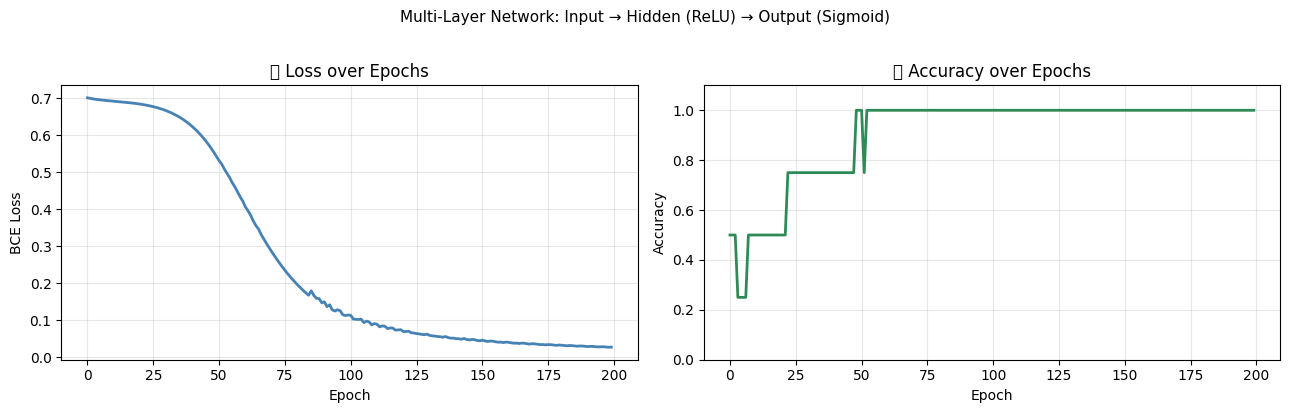

In [ ]:
# ============================================================
# 📊 Visualise Training — Multi-Layer Network
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history_multi.history['loss'], color='steelblue', linewidth=2)
ax1.set_title('📉 Loss over Epochs', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(history_multi.history['accuracy'], color='seagreen', linewidth=2)
ax2.set_title('📈 Accuracy over Epochs', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim([0, 1.1])
ax2.grid(True, alpha=0.3)

plt.suptitle('Multi-Layer Network: Input → Hidden (ReLU) → Output (Sigmoid)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 🔬 Inspect What the Network Learned

In [ ]:
# ============================================================
# 🔬 Inspect Learned Weights
# ============================================================

hidden_layer = model_multi.get_layer('hidden_layer')
output_layer = model_multi.get_layer('output_layer')

W1_learned, b1_learned = hidden_layer.get_weights()
W2_learned, b2_learned = output_layer.get_weights()

print('🔬 Learned Weights After Training')
print()
print('Hidden Layer Weights (Input → Hidden):')
print(f'  W1 shape: {W1_learned.shape}  (2 inputs × 3 hidden neurons)')
print(f'  W1 = \n{W1_learned.round(3)}')
print(f'  b1 = {b1_learned.round(3)}')
print()
print('Output Layer Weights (Hidden → Output):')
print(f'  W2 shape: {W2_learned.shape}  (3 hidden × 1 output)')
print(f'  W2 = {W2_learned.flatten().round(3)}')
print(f'  b2 = {b2_learned.round(3)}')

🔬 Learned Weights After Training

Hidden Layer Weights (Input → Hidden):
  W1 shape: (2, 3)  (2 inputs × 3 hidden neurons)
  W1 = 
[[ 3.888  0.075  0.267]
 [-1.312 -0.293 -0.795]]
  b1 = [-0.42  0.    0.  ]

Output Layer Weights (Hidden → Output):
  W2 shape: (3, 1)  (3 hidden × 1 output)
  W2 = [ 4.062 -1.092  0.211]
  b2 = [-3.135]


---
# 🗺️ Architecture Visualisation

/tmp/ipykernel_7304/1576460943.py:57: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


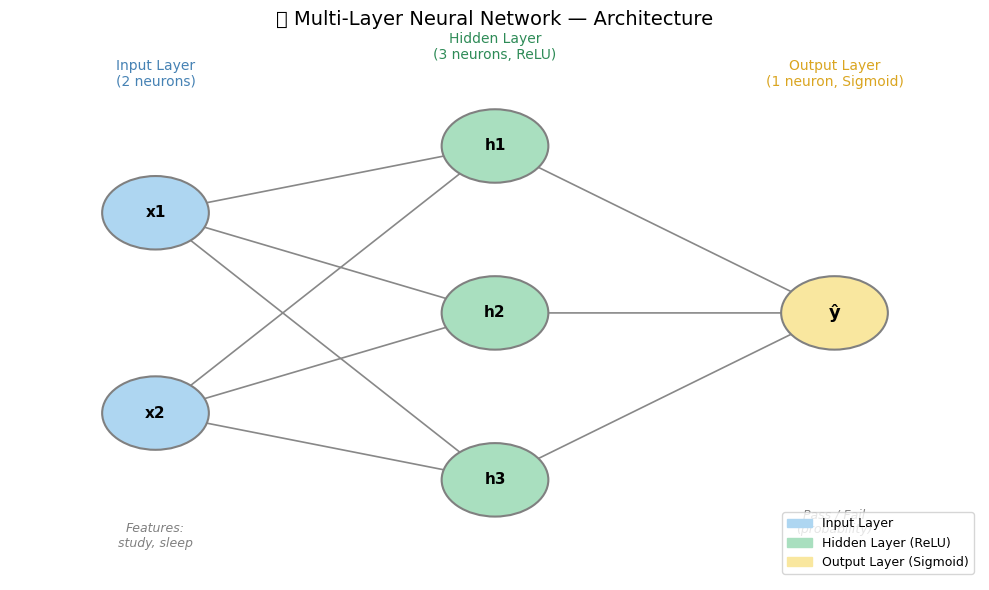

In [ ]:
# ============================================================
# 🎨 Neural Network Diagram
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.axis('off')
ax.set_title('🧠 Multi-Layer Neural Network — Architecture', fontsize=14, pad=15)

# Node positions
input_pos  = [(1.5, 5.5), (1.5, 2.5)]
hidden_pos = [(5.0, 6.5), (5.0, 4.0), (5.0, 1.5)]
output_pos = [(8.5, 4.0)]

colors = {'input': '#AED6F1', 'hidden': '#A9DFBF', 'output': '#F9E79F'}

def draw_node(ax, pos, label, color, fontsize=11):
    circle = plt.Circle(pos, 0.55, color=color, ec='gray', linewidth=1.5, zorder=3)
    ax.add_patch(circle)
    ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=fontsize, fontweight='bold', zorder=4)

def draw_arrow(ax, src, dst):
    ax.annotate('', xy=dst, xytext=src,
                arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2),
                zorder=2)

# Draw connections
for s in input_pos:
    for d in hidden_pos:
        draw_arrow(ax, s, d)
for s in hidden_pos:
    for d in output_pos:
        draw_arrow(ax, s, d)

# Draw nodes
for i, pos in enumerate(input_pos):
    draw_node(ax, pos, f'x{i+1}', colors['input'])
for i, pos in enumerate(hidden_pos):
    draw_node(ax, pos, f'h{i+1}', colors['hidden'])
draw_node(ax, output_pos[0], 'ŷ', colors['output'], fontsize=13)

# Labels
ax.text(1.5, 7.4, 'Input Layer\n(2 neurons)', ha='center', fontsize=10, color='steelblue')
ax.text(5.0, 7.8, 'Hidden Layer\n(3 neurons, ReLU)', ha='center', fontsize=10, color='seagreen')
ax.text(8.5, 7.4, 'Output Layer\n(1 neuron, Sigmoid)', ha='center', fontsize=10, color='goldenrod')

ax.text(1.5, 0.5, 'Features:\nstudy, sleep', ha='center', fontsize=9, style='italic', color='gray')
ax.text(8.5, 0.7, 'Pass / Fail\n(probability)', ha='center', fontsize=9, style='italic', color='gray')

# Legend
patches = [
    mpatches.Patch(color=colors['input'],  label='Input Layer'),
    mpatches.Patch(color=colors['hidden'], label='Hidden Layer (ReLU)'),
    mpatches.Patch(color=colors['output'], label='Output Layer (Sigmoid)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

---
# 🏁 Summary

## What We Learned Today

| Concept              | Formula                                      | Where We Used It              |
|----------------------|----------------------------------------------|-------------------------------|
| **Weighted Sum**     | $z = w_1x_1 + w_2x_2 + b$                   | Every neuron, every layer     |
| **Linear Activation**| $\hat{y}=z$                                  | Regression output             |
| **Sigmoid Activation**| $\sigma(z)=\frac{1}{1+e^{-z}}$              | Classification output         |
| **ReLU Activation**  | $\max(0,z)$                                  | Hidden layers                 |
| **MSE Loss**         | $(y-\hat{y})^2$                              | Regression                    |
| **BCE Loss**         | $-\bigl[y\log(\hat{y})+(1-y)\log(1-\hat{y})\bigr]$ | Classification           |
| **Backpropagation**  | Chain Rule                                   | Compute gradients             |
| **Gradient Descent** | $w := w - \eta \nabla L$                     | Update weights                |
---

- **Weighted Sum:** $z = w_1x_1 + w_2x_2 + b$
- **Linear Activation:** $\hat{y}=z$
- **Sigmoid Activation:** $\sigma(z)=\frac{1}{1+e^{-z}}$
- **ReLU Activation:** $\max(0,z)$
- **MSE Loss:** $(y-\hat{y})^2$
- **BCE Loss:** $-\left[y\log(\hat{y})+(1-y)\log(1-\hat{y})\right]$
- **Backpropagation:** Chain Rule
- **Gradient Descent:** $w := w-\eta\nabla L$
## ✅ Key Takeaways

1. **Every neuron does the same thing**: weighted sum → activation → output
2. **Loss measures how wrong we are** — lower is better
3. **Backpropagation** tells us *how much* each weight is to blame for the error
4. **Gradient Descent** nudges the weights in the right direction
5. **Keras does all of this automatically** — but now you know the maths behind it!

---

## 🚀 What's Next?

- **Demo 2**: See pretrained models in action (CNNs, Transformers)
- **Explore**: Try changing the learning rate and see how it affects training
- **Experiment**: Add more hidden layers — what happens to accuracy?
---